<a href="https://colab.research.google.com/github/priyanka22wh1a1264/DataAnalysis/blob/main/youtube_dataanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#youtube Analysis

In [ ]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loading the dataset
df=pd.read_csv("https://github.com/Taj1920/Data_Analysis/raw/refs/heads/main/Youtube_analysis/YOUTUBE%20CHANNELS%20DATASET.csv")
df

,Ranking,Username,Subscribers,Uploads,Views,Country
0,1.0,MrBeast,336M,838,"66,853,633,536",US
1,2.0,T-Series,281M,"22,313","277,242,795,553",IN
2,3.0,Cocomelon-Nursery Rhymes,186M,1370,"194,361,752,276",US
3,4.0,Youtube Movies,185M,0,0,NaN
4,5.0,Set India,180M,"148,727","172,709,029,653",IN
...,...,...,...,...,...,...
96,97.0,Voce Sabia,46M,"1,714","8,180,068,059",BR
97,98.0,Katy Perry,45.6M,170,"27,616,850,074",US
98,99.0,Speed Records,45.5M,"11,880","30,587,436,800",IN
99,100.0,Zhong,45.5M,"1,861","17,998,163,730",US


#EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ranking      100 non-null    float64
 1   Username     100 non-null    object 
 2   Subscribers  100 non-null    object 
 3   Uploads      100 non-null    object 
 4   Views        100 non-null    object 
 5   Country      94 non-null     object 
dtypes: float64(1), object(5)
memory usage: 4.9+ KB


In [ ]:
df.isnull().sum()

,0
Ranking,1
Username,1
Subscribers,1
Uploads,1
Views,1
Country,7


In [ ]:
#handling null values
df["Ranking"].unique()
mean = df["Ranking"].mean()
df["Ranking"] = df["Ranking"].fillna(mean)
df["Ranking"] = df["Ranking"].astype(int)
df["Ranking"].unique()
df.isnull().sum()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Ranking      101 non-null    int64 
 1   Username     100 non-null    object
 2   Subscribers  100 non-null    object
 3   Uploads      100 non-null    object
 4   Views        100 non-null    object
 5   Country      94 non-null     object
dtypes: int64(1), object(5)
memory usage: 4.9+ KB


In [ ]:
#handling username col
df["Username"].unique()
df["Username"] = df["Username"].fillna("Other Channel")
df["Username"].unique()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Ranking      101 non-null    int64 
 1   Username     101 non-null    object
 2   Subscribers  100 non-null    object
 3   Uploads      100 non-null    object
 4   Views        100 non-null    object
 5   Country      94 non-null     object
dtypes: int64(1), object(5)
memory usage: 4.9+ KB


In [ ]:
#handling subscribers col replacing missing values with median
df["Subscribers"].unique()
df["Subscribers"] = df["Subscribers"].str.replace("M", "")
df["Subscribers"] = df["Subscribers"].astype(float)
df["Subscribers"] = df["Subscribers"]*1000000
med=df["Subscribers"].median()
df["Subscribers"] = df["Subscribers"].fillna(med)
df["Subscribers"] = df["Subscribers"].astype(int)
df["Subscribers"].unique()
df.isnull().sum()


,0
Ranking,0
Username,0
Subscribers,0
Uploads,1
Views,1
Country,7


In [ ]:
#handling uploads col converting it to int
df["Uploads"].unique()
df["Uploads"] = df["Uploads"].fillna("0")
df["Uploads"] = df["Uploads"].str.replace(",","")
df["Uploads"] = df["Uploads"].astype(int)
df["Uploads"].unique()
df.info()
df["Uploads"].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Ranking      101 non-null    int64 
 1   Username     101 non-null    object
 2   Subscribers  101 non-null    int64 
 3   Uploads      101 non-null    int64 
 4   Views        100 non-null    object
 5   Country      94 non-null     object
dtypes: int64(3), object(3)
memory usage: 4.9+ KB


array([   838,  22313,   1370,      0, 148727,    796,   1282,    918,
        12787,   4800,  80964,    335,   9421,  94136,    603,    832,
       190672,   7391,   2674,   3399, 179052,   2253,    249,   3580,
        29140,     80,    971,   6859,   8988,   1413,  19224, 415087,
         1396,   3014,   1667,    731,  20481,    196, 152148,  41711,
         5941,   4333,   2873,    187,    463,    285,   1435, 155545,
          933,   1221,    508,   2655,  13166,   1143,   1158,    538,
          214,  11966,    142,   3468,   2072,   3688,   2009,   2909,
         2264,   1070, 234889,   6907, 111513,   9550,   3028,   1735,
         2915,    636,    157,    547,   4792,   4763,  24021,   1857,
          123,    362,   1921,   1193,   5310,   1334,   3201, 433181,
          916,    676,    314,    141,   1831,   1714,    170,  11880,
         1861])

In [ ]:
#handling views col
df["Views"].unique()
df["Views"] = df["Views"].str.replace(",","")
df["Views"] = df["Views"].fillna("0")
df["Views"] = df["Views"].astype(float)
df["Views"] = df["Views"].fillna("0")
df["Views"] = df["Views"].astype(int)
df["Views"].unique()
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Ranking      101 non-null    int64 
 1   Username     101 non-null    object
 2   Subscribers  101 non-null    int64 
 3   Uploads      101 non-null    int64 
 4   Views        101 non-null    int64 
 5   Country      94 non-null     object
dtypes: int64(4), object(2)
memory usage: 4.9+ KB


In [ ]:
#replacing missing values in country with mode
df[df["Country"].isnull()]
mode=df["Country"].mode()[0]
df["Country"] = df["Country"].fillna(mode)
df["Country"].unique()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Ranking      101 non-null    int64 
 1   Username     101 non-null    object
 2   Subscribers  101 non-null    int64 
 3   Uploads      101 non-null    int64 
 4   Views        101 non-null    int64 
 5   Country      101 non-null    object
dtypes: int64(4), object(2)
memory usage: 4.9+ KB


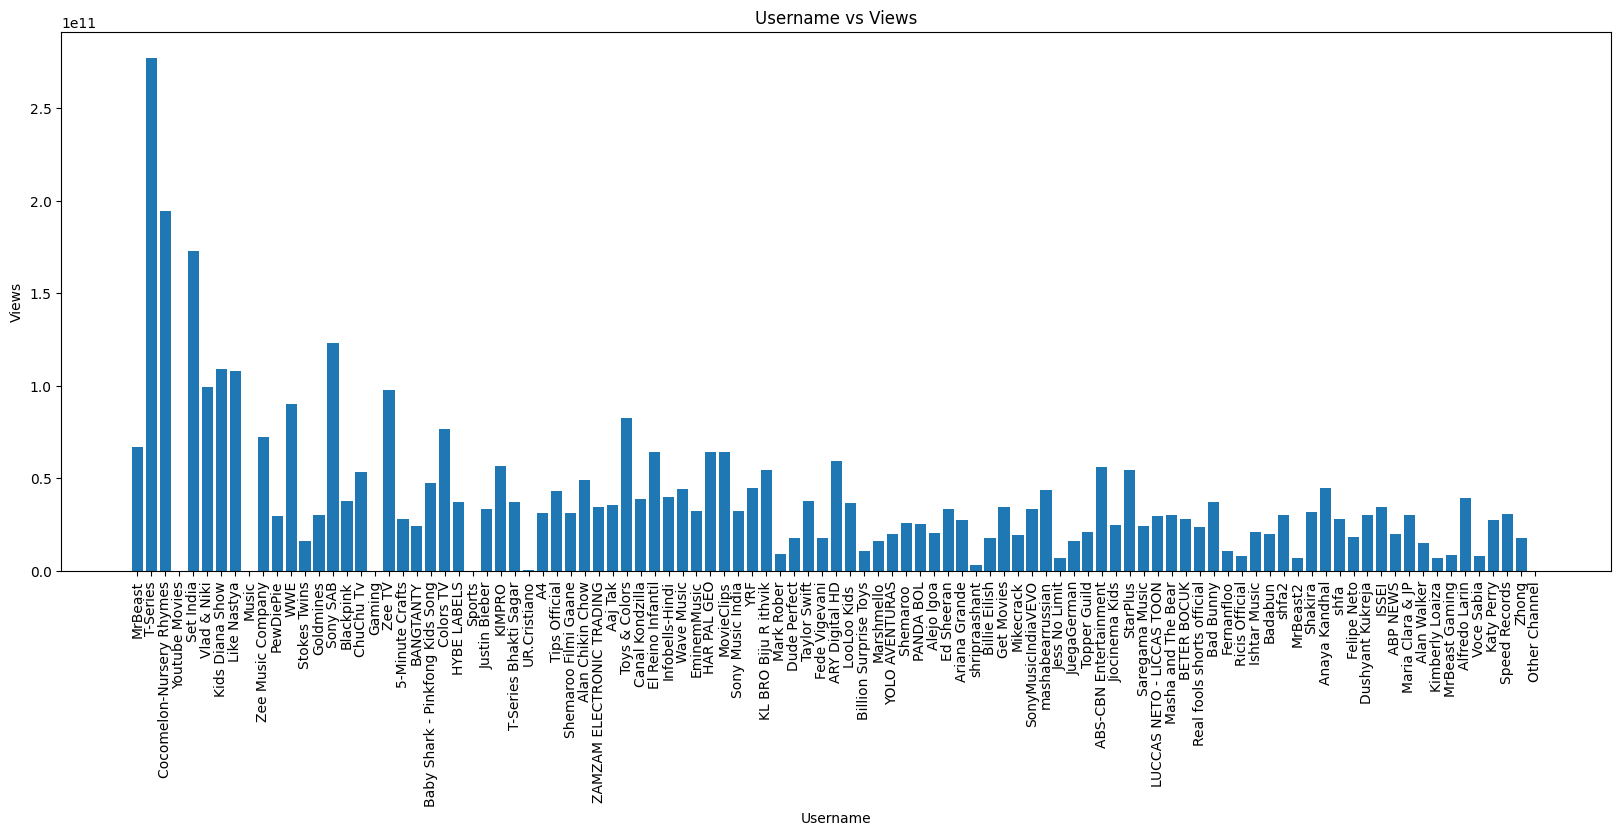

In [ ]:
#graph for which channel have more views
plt.figure(figsize=(20,7))
plt.xticks(rotation=90)
plt.bar(df["Username"],df["Views"])
plt.title("Username vs Views")
plt.xlabel("Username")
plt.ylabel("Views")
plt.show()

people have less interest for youtube movies , music, gaming, sports, other channels

T-Series has the highest total views

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Ranking      101 non-null    int64 
 1   Username     101 non-null    object
 2   Subscribers  101 non-null    int64 
 3   Uploads      101 non-null    int64 
 4   Views        101 non-null    int64 
 5   Country      101 non-null    object
dtypes: int64(4), object(2)
memory usage: 4.9+ KB


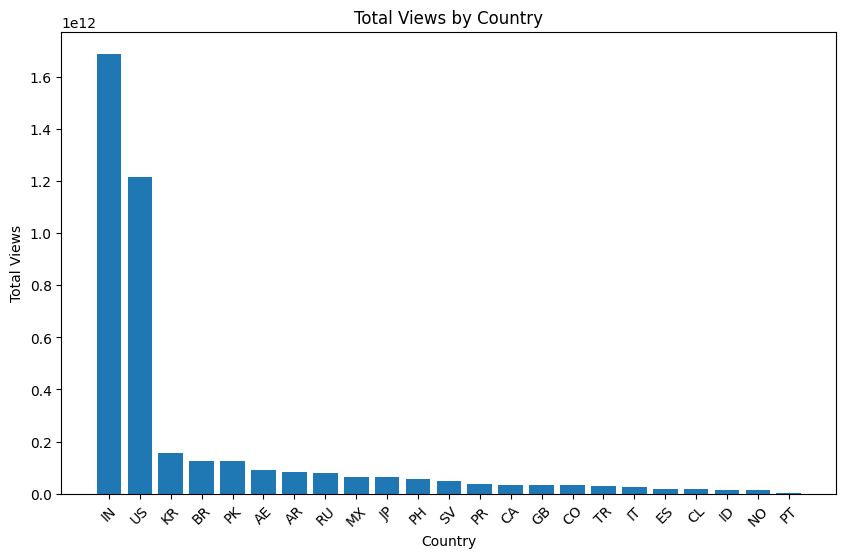

In [ ]:
#which country have more views
# df=df.groupby("Country")["Views"].sum()
# plt.barplot()
country_views = df.groupby("Country")["Views"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.bar(country_views.index, country_views.values)
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Total Views")
plt.title("Total Views by Country")
plt.show()

India has the highest total views

US is the second highest

All other countries have significantly lower views compared to India and the US


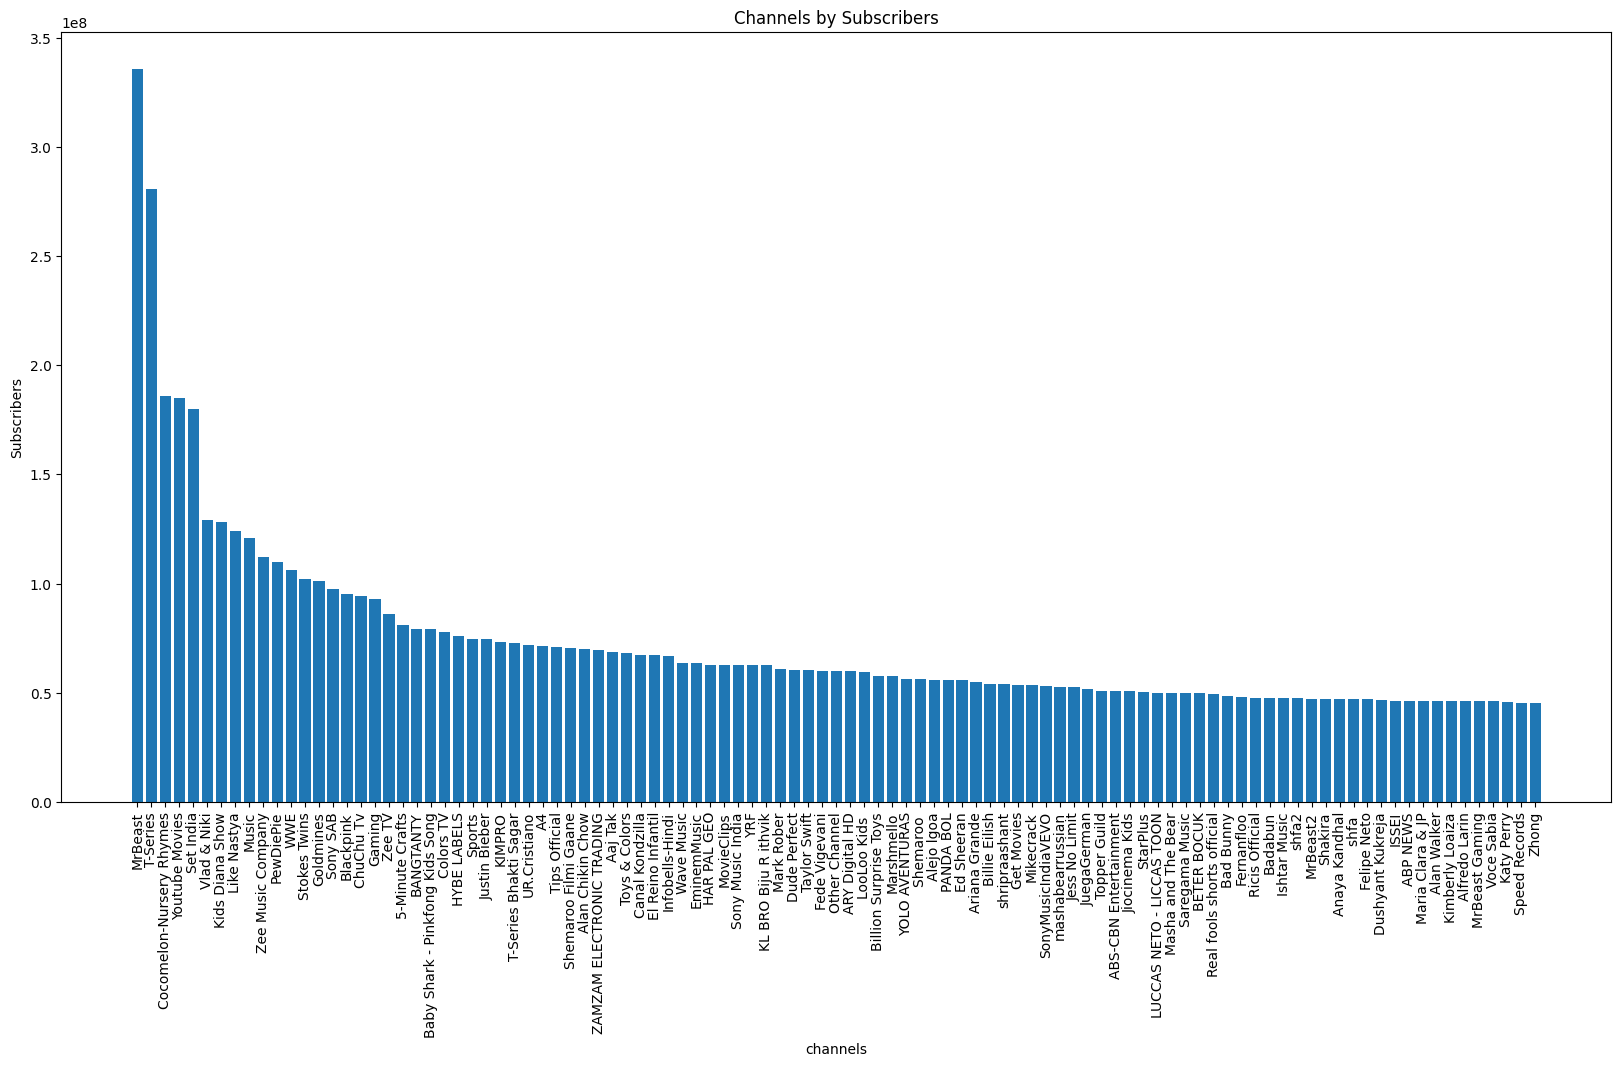

In [ ]:
#which channels have more subscribers
top= df.sort_values("Subscribers", ascending=False)
plt.figure(figsize=(20,10))
plt.bar(top["Username"], top["Subscribers"])
plt.xticks(rotation=90)
plt.xlabel("channels")
plt.ylabel("Subscribers")
plt.title("Channels by Subscribers")
plt.show()

Mr-Beast has highest number of subcribers

T-Series holds the second position in subscribers

The first 4 to 5 channels have significantly higher subscribers compared to others


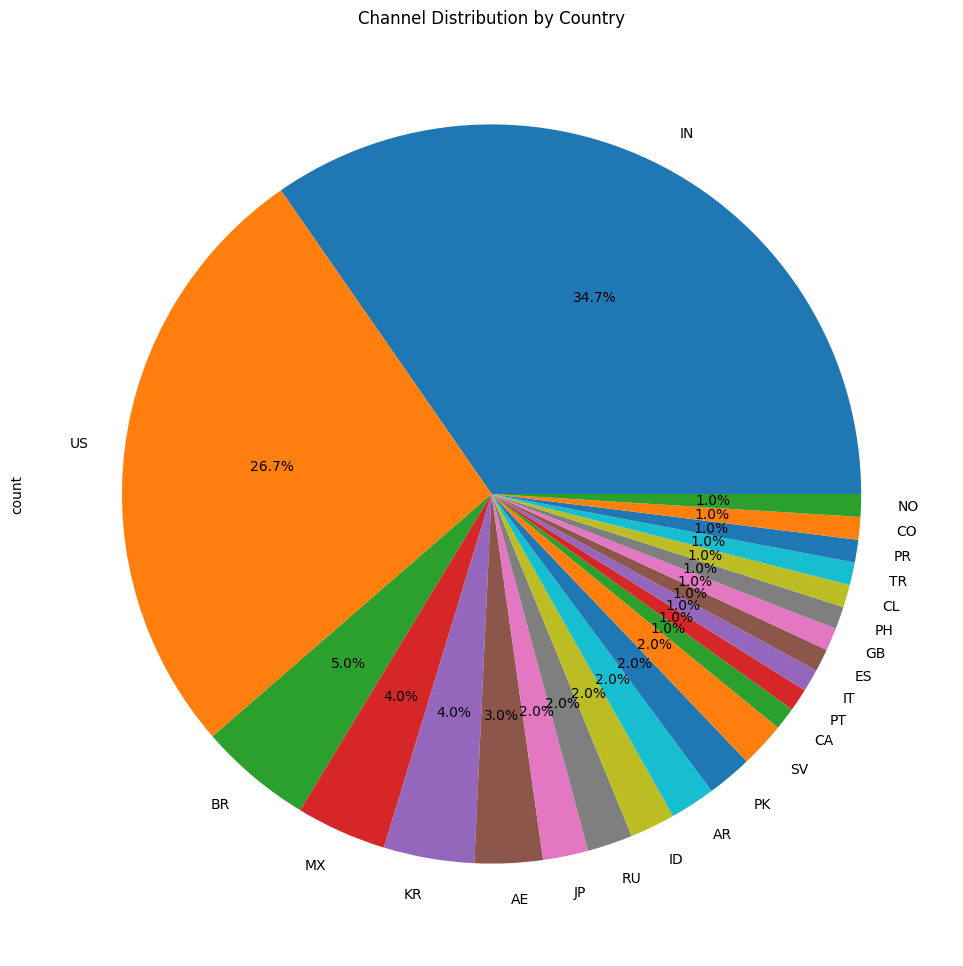

In [ ]:
plt.figure(figsize=(12,12))
df["Country"].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Channel Distribution by Country")
plt.show()

India has the highest number of channels

Most of the top channels belong to India and the US

Other countries have very few channels

**Insights :**

1.T-Series has the highest total views

2.India has the highest total views

3.MrBeast has the highest subscribers

4.Most top channels belong to India and the US

**Recommendations :**

1.YouTube Movies, Music, Gaming, and Sports channels should improve content quality and increase upload frequency to attract more viewers

2.The number of channels should increase in countries other than India and the US so that both viewers and overall views can grow globally

